<a href="https://colab.research.google.com/github/jashvidesai2030/IEMS447FinalProject/blob/main/IEMS447FinalDiabetesSex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 — Loading CDC Diabetes Health Indicators dataset (id=891)

Feature matrix shape : (253680, 21)
Target shape         : (253680, 1)
Target column name(s): ['Diabetes_binary']

Target value counts:
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

Sex value counts (0=Female, 1=Male):
Sex
0    141974
1    111706
Name: count, dtype: int64

STEP 2 — Preparing binary outcome variable
Target is already binary  (0=no diabetes, 1=diabetes). Using as-is.

Final 'diabetes_binary' value counts:
  0 (no diabetes): 218,334  (86.1%)
  1 (diabetes): 35,346  (13.9%)

STEP 3 — Defining fairness group: Sex

Sex group mapping used throughout this study:
  0 → Female  (141,974 patients, 56.0%)
  1 → Male    (111,706 patients, 44.0%)

STEP 4 — 70/30 stratified train-test split (random_state=42)

Train size : 177,576  (70.0%)
Test size  : 76,104  (30.0%)
Test diabetes prevalence: 13.9%

STEP 5 — Training Logistic Regression (StandardScaler + class_weight='balanced')

Model trained succ

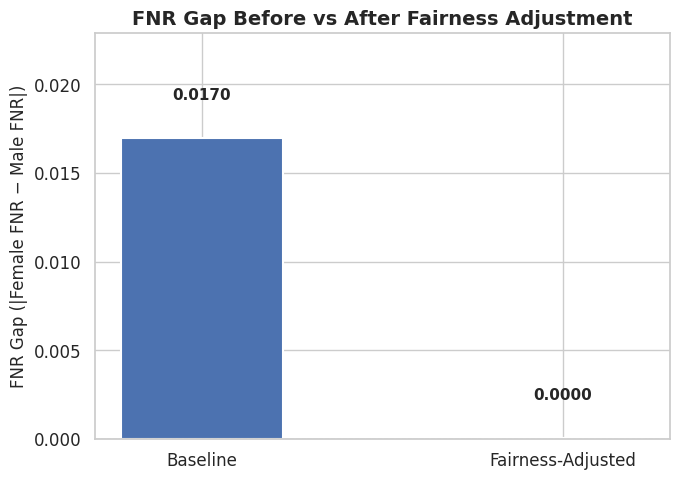

  ✓ chart1_fnr_gap.png


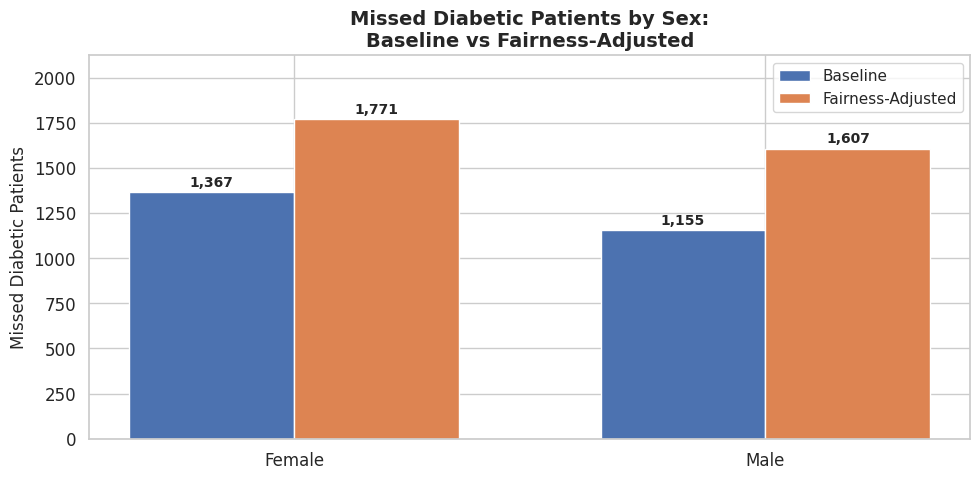

  ✓ chart2_missed_by_sex.png


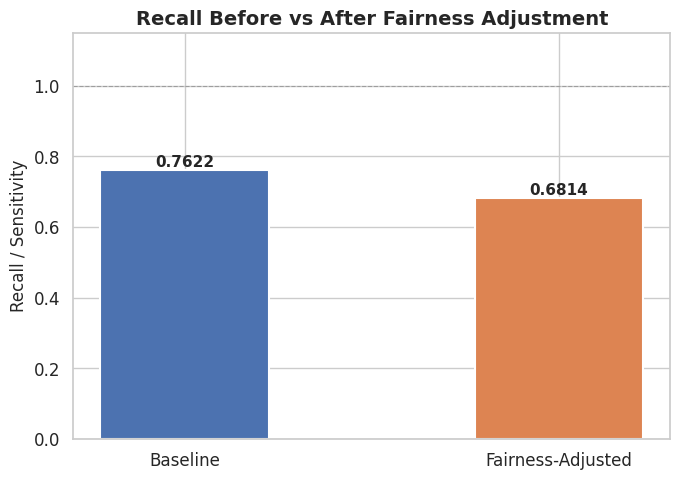

  ✓ chart3_recall.png


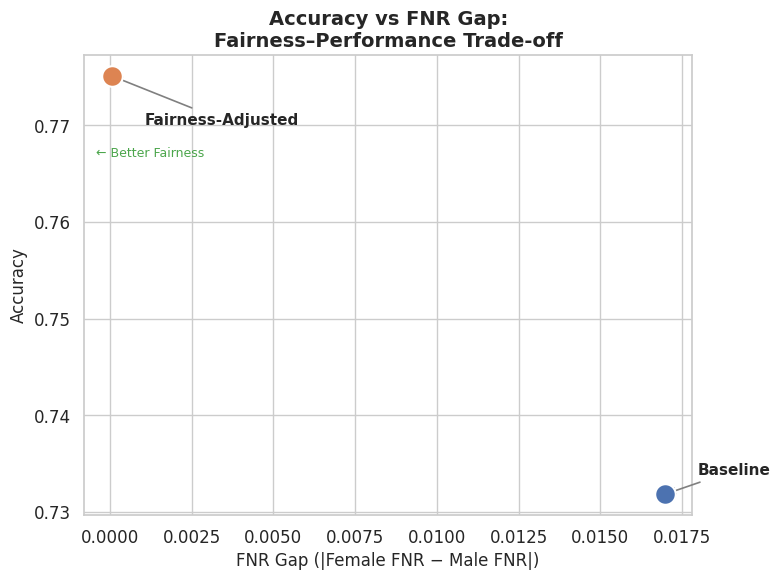

  ✓ chart4_accuracy_vs_fnr_gap.png


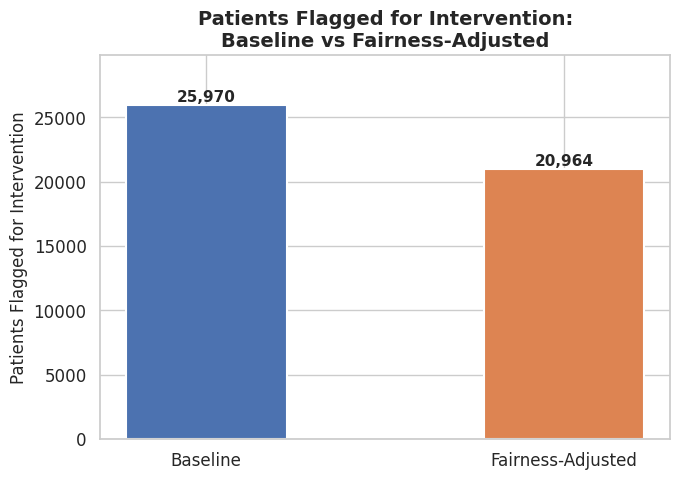

  ✓ chart5_flagged.png

STEP 10 — Interpretive Summary

╔══════════════════════════════════════════════════════════════════════╗
║                   INTERPRETATION OF RESULTS                         ║
╠══════════════════════════════════════════════════════════════════════╣

  1. FNR GAP (Fairness Criterion)
     ✓ REDUCED
     Baseline FNR gap   : 0.0170
     Adjusted FNR gap   : 0.0000
     → Fairness adjustment successfully reduced the sex-based disparity
       in missed-diabetic rates between female and male patients.

  2. ACCURACY
     Change: +0.0433 (+4.33%)
     → Accuracy improved.
       The objective function penalises accuracy loss, so the search
       was designed to minimise this trade-off.

  3. RECALL / SENSITIVITY
     Baseline : 0.7622
     Adjusted : 0.6814
     → Recall decreased after adjustment.
       More diabetic patients are missed overall
       (+856 patients).

  4. CLINICAL & FAIRNESS IMPLICATIONS
     • Group-specific thresholds allow the model to accom

In [1]:
"""
=============================================================================
CDC Diabetes Health Indicators — Fairness-Adjusted Decision Threshold Study
=============================================================================
Research Question:
    How do fairness interventions affect treatment allocation and missed
    patients in healthcare risk prediction?

Fairness Definition Used:
    Equalised False Negative Rate (FNR) across sex groups.
    A high FNR for a group means diabetic patients in that group are
    disproportionately missed — a clinically serious equity concern.
=============================================================================
"""

# ── Standard library ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Third-party ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix)

# ── Aesthetic constants ───────────────────────────────────────────────────
PALETTE   = {"Baseline": "#4C72B0", "Fairness-Adjusted": "#DD8452"}
FIG_SIZE  = (10, 5)
BAR_WIDTH = 0.35
TITLE_FS  = 14
LABEL_FS  = 12


# =============================================================================
# 1. LOAD DATASET
# =============================================================================
print("=" * 70)
print("STEP 1 — Loading CDC Diabetes Health Indicators dataset (id=891)")
print("=" * 70)

# Fetch dataset directly from UCI ML Repository
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# Extract features and targets as pandas DataFrames
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Target column name(s): {y.columns.tolist()}")
print(f"\nTarget value counts:\n{y.iloc[:, 0].value_counts().sort_index()}")
print(f"\nSex value counts (0=Female, 1=Male):\n{X['Sex'].value_counts().sort_index()}")

# =============================================================================
# 2. PREPARE OUTCOME VARIABLE
# =============================================================================
print("\n" + "=" * 70)
print("STEP 2 — Preparing binary outcome variable")
print("=" * 70)

raw_target = y.iloc[:, 0]
unique_vals = set(raw_target.unique())

if unique_vals <= {0, 1}:
    # Already binary — 0=no diabetes, 1=diabetes
    diabetes_binary = raw_target.values.astype(int)
    print("Target is already binary  (0=no diabetes, 1=diabetes). Using as-is.")
elif unique_vals <= {0, 1, 2}:
    # Three-class encoding: 2=diabetes, 0/1=not diabetes
    diabetes_binary = (raw_target == 2).astype(int).values
    print("Three-class target detected. Recoded: 2→1 (diabetes), 0/1→0 (no diabetes).")
else:
    raise ValueError(f"Unexpected target values: {unique_vals}")

print(f"\nFinal 'diabetes_binary' value counts:")
unique, counts = np.unique(diabetes_binary, return_counts=True)
for v, c in zip(unique, counts):
    label = "diabetes" if v == 1 else "no diabetes"
    print(f"  {v} ({label}): {c:,}  ({100*c/len(diabetes_binary):.1f}%)")

# =============================================================================
# 3. DEFINE FAIRNESS GROUP
# =============================================================================
print("\n" + "=" * 70)
print("STEP 3 — Defining fairness group: Sex")
print("=" * 70)

SEX_MAP = {0: "Female", 1: "Male"}   # clearly labelled mapping
sex_col = X["Sex"].values.astype(int)

print(f"\nSex group mapping used throughout this study:")
for code, label in SEX_MAP.items():
    n = (sex_col == code).sum()
    print(f"  {code} → {label:6s}  ({n:,} patients, "
          f"{100*n/len(sex_col):.1f}%)")

# =============================================================================
# 4. TRAIN / TEST SPLIT
# =============================================================================
print("\n" + "=" * 70)
print("STEP 4 — 70/30 stratified train-test split (random_state=42)")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, diabetes_binary,
    test_size=0.30,
    random_state=42,
    stratify=diabetes_binary   # preserve class prevalence
)

sex_test = X_test["Sex"].values.astype(int)   # group labels for test set

print(f"\nTrain size : {len(X_train):,}  ({100*len(X_train)/len(X):.1f}%)")
print(f"Test size  : {len(X_test):,}  ({100*len(X_test)/len(X):.1f}%)")
print(f"Test diabetes prevalence: "
      f"{100*y_test.mean():.1f}%")

# =============================================================================
# 5. TRAIN LOGISTIC REGRESSION MODEL
# =============================================================================
print("\n" + "=" * 70)
print("STEP 5 — Training Logistic Regression (StandardScaler + class_weight='balanced')")
print("=" * 70)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced",
                                  random_state=42))
])

pipeline.fit(X_train, y_train)

# Predicted probability of diabetes (positive class = 1)
risk_scores = pipeline.predict_proba(X_test)[:, 1]

print("\nModel trained successfully.")
print(f"Risk score range on test set: [{risk_scores.min():.4f}, "
      f"{risk_scores.max():.4f}]")

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def apply_threshold(scores, threshold):
    """Return binary predictions given a single global threshold."""
    return (scores >= threshold).astype(int)


def apply_group_thresholds(scores, sex, female_thresh, male_thresh):
    """Return binary predictions using sex-specific thresholds."""
    preds = np.zeros(len(scores), dtype=int)
    preds[sex == 0] = (scores[sex == 0] >= female_thresh).astype(int)
    preds[sex == 1] = (scores[sex == 1] >= male_thresh).astype(int)
    return preds


def compute_metrics(y_true, y_pred, sex, risk_scores=None):
    """
    Compute a comprehensive set of fairness and performance metrics.

    Returns a dict with accuracy, precision, recall, FNR overall and
    by sex group, patients flagged, and missed diabetic patients.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)

    # False Negative Rate = FN / (FN + TP) = 1 − recall
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fnr_overall = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # Per-group FNR
    def group_fnr(mask):
        yt, yp = y_true[mask], y_pred[mask]
        _, _, fn_g, tp_g = confusion_matrix(yt, yp).ravel()
        return fn_g / (fn_g + tp_g) if (fn_g + tp_g) > 0 else 0.0

    female_mask = (sex == 0)
    male_mask   = (sex == 1)

    fnr_f = group_fnr(female_mask)
    fnr_m = group_fnr(male_mask)

    # Missed diabetics by group (false negatives)
    missed_f = int(((y_true == 1) & (y_pred == 0) & female_mask).sum())
    missed_m = int(((y_true == 1) & (y_pred == 0) & male_mask).sum())

    return {
        "accuracy":        acc,
        "precision":       prec,
        "recall":          rec,
        "fnr":             fnr_overall,
        "fnr_female":      fnr_f,
        "fnr_male":        fnr_m,
        "fnr_gap":         abs(fnr_f - fnr_m),
        "flagged":         int(y_pred.sum()),
        "missed_total":    int(fn),
        "missed_female":   missed_f,
        "missed_male":     missed_m,
    }


def print_metrics(label, m, threshold_info=""):
    """Pretty-print a metrics dict."""
    print(f"\n{'─'*60}")
    print(f"  {label}  {threshold_info}")
    print(f"{'─'*60}")
    print(f"  Accuracy                : {m['accuracy']:.4f}")
    print(f"  Precision               : {m['precision']:.4f}")
    print(f"  Recall / Sensitivity    : {m['recall']:.4f}")
    print(f"  False Negative Rate     : {m['fnr']:.4f}")
    print(f"  Patients flagged        : {m['flagged']:,}")
    print(f"  Missed diabetic patients: {m['missed_total']:,}")
    print(f"  Female FNR              : {m['fnr_female']:.4f}")
    print(f"  Male FNR                : {m['fnr_male']:.4f}")
    print(f"  FNR gap (|F−M|)         : {m['fnr_gap']:.4f}")

# =============================================================================
# 6. BASELINE DECISION RULE  (single global threshold = 0.50)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 6 — Baseline Rule: single threshold = 0.50")
print("=" * 70)

BASELINE_THRESH = 0.50

y_pred_base = apply_threshold(risk_scores, BASELINE_THRESH)
metrics_base = compute_metrics(y_test, y_pred_base, sex_test)

print_metrics("BASELINE", metrics_base,
              f"(threshold = {BASELINE_THRESH})")

# =============================================================================
# 7. FAIRNESS-ADJUSTED DECISION RULE (group-specific thresholds)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 7 — Fairness-Adjusted Rule: sex-specific threshold search")
print("=" * 70)

CANDIDATES = np.arange(0.20, 0.81, 0.01)   # 61 candidate thresholds
baseline_acc = metrics_base["accuracy"]

best_obj       = np.inf
best_f_thresh  = BASELINE_THRESH
best_m_thresh  = BASELINE_THRESH
best_metrics_f = metrics_base

print(f"\nSearching {len(CANDIDATES)}×{len(CANDIDATES)} = "
      f"{len(CANDIDATES)**2:,} threshold combinations …")

for f_thresh in CANDIDATES:
    for m_thresh in CANDIDATES:
        y_pred_fair = apply_group_thresholds(
            risk_scores, sex_test, f_thresh, m_thresh
        )
        m = compute_metrics(y_test, y_pred_fair, sex_test)

        recall_gap   = m["fnr_gap"]                          # FNR gap to minimise
        accuracy_loss = baseline_acc - m["accuracy"]         # penalty if accuracy drops
        objective    = recall_gap + 0.5 * max(accuracy_loss, 0)

        if objective < best_obj:
            best_obj       = objective
            best_f_thresh  = f_thresh
            best_m_thresh  = m_thresh
            best_metrics_f = m

print(f"\nOptimal thresholds found:")
print(f"  Female threshold : {best_f_thresh:.2f}")
print(f"  Male threshold   : {best_m_thresh:.2f}")
print(f"  Objective value  : {best_obj:.6f}")

print_metrics("FAIRNESS-ADJUSTED", best_metrics_f,
              f"(female_thresh={best_f_thresh:.2f}, "
              f"male_thresh={best_m_thresh:.2f})")

# =============================================================================
# 8. SUMMARY TABLE
# =============================================================================
print("\n" + "=" * 70)
print("STEP 8 — Summary Comparison Table")
print("=" * 70)

def pct(val):
    return f"{val:.1%}"

def delta(new, base):
    diff = new - base
    sign = "+" if diff >= 0 else ""
    return f"{sign}{diff:.1%}"

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Patients Flagged",
        "Missed Diabetic Patients",
        "Female FNR",
        "Male FNR",
        "FNR Gap",
        "Accuracy Change vs Baseline",
        "Change in Missed Patients",
    ],
    "Baseline": [
        pct(metrics_base["accuracy"]),
        pct(metrics_base["precision"]),
        pct(metrics_base["recall"]),
        f"{metrics_base['flagged']:,}",
        f"{metrics_base['missed_total']:,}",
        pct(metrics_base["fnr_female"]),
        pct(metrics_base["fnr_male"]),
        pct(metrics_base["fnr_gap"]),
        "—",
        "—",
    ],
    "Fairness-Adjusted": [
        pct(best_metrics_f["accuracy"]),
        pct(best_metrics_f["precision"]),
        pct(best_metrics_f["recall"]),
        f"{best_metrics_f['flagged']:,}",
        f"{best_metrics_f['missed_total']:,}",
        pct(best_metrics_f["fnr_female"]),
        pct(best_metrics_f["fnr_male"]),
        pct(best_metrics_f["fnr_gap"]),
        delta(best_metrics_f["accuracy"], metrics_base["accuracy"]),
        (f"{best_metrics_f['missed_total'] - metrics_base['missed_total']:+,}"),
    ],
})

print("\n" + summary.to_string(index=False))

# =============================================================================
# 9. VISUALISATIONS
# =============================================================================
print("\n" + "=" * 70)
print("STEP 9 — Generating charts …")
print("=" * 70)

sns.set_theme(style="whitegrid", font_scale=1.1)

# ── Helper: annotate bars ─────────────────────────────────────────────────
def annotate_bars(ax, fmt="{:.3f}", fontsize=11):
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + 0.002, fmt.format(h),
                    ha="center", va="bottom", fontsize=fontsize, fontweight="bold")


# ─────────────────────────────────────────────────────────────────────────────
# Chart 1 — FNR Gap: Baseline vs Fairness-Adjusted
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
labels  = ["Baseline", "Fairness-Adjusted"]
values  = [metrics_base["fnr_gap"], best_metrics_f["fnr_gap"]]
colors  = [PALETTE["Baseline"], PALETTE["Fairness-Adjusted"]]
bars    = ax.bar(labels, values, color=colors, width=0.45, edgecolor="white", linewidth=1.5)

annotate_bars(ax, fmt="{:.4f}")
ax.set_ylabel("FNR Gap (|Female FNR − Male FNR|)", fontsize=LABEL_FS)
ax.set_title("FNR Gap Before vs After Fairness Adjustment", fontsize=TITLE_FS, fontweight="bold")
ax.set_ylim(0, max(values) * 1.35)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()
print("  ✓ chart1_fnr_gap.png")


# ─────────────────────────────────────────────────────────────────────────────
# Chart 2 — Missed Diabetic Patients by Sex: Baseline vs Fairness-Adjusted
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIG_SIZE)
x = np.array([0, 1])   # Female, Male
missed_base  = [metrics_base["missed_female"],   metrics_base["missed_male"]]
missed_fair  = [best_metrics_f["missed_female"], best_metrics_f["missed_male"]]

rects1 = ax.bar(x - BAR_WIDTH/2, missed_base, BAR_WIDTH,
                label="Baseline",          color=PALETTE["Baseline"],          edgecolor="white")
rects2 = ax.bar(x + BAR_WIDTH/2, missed_fair, BAR_WIDTH,
                label="Fairness-Adjusted", color=PALETTE["Fairness-Adjusted"], edgecolor="white")

for rect in list(rects1) + list(rects2):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 15,
            f"{int(h):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["Female", "Male"], fontsize=LABEL_FS)
ax.set_ylabel("Missed Diabetic Patients", fontsize=LABEL_FS)
ax.set_title("Missed Diabetic Patients by Sex:\nBaseline vs Fairness-Adjusted",
             fontsize=TITLE_FS, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, max(missed_base + missed_fair) * 1.20)
plt.tight_layout()
plt.show()
print("  ✓ chart2_missed_by_sex.png")


# ─────────────────────────────────────────────────────────────────────────────
# Chart 3 — Recall (Sensitivity): Baseline vs Fairness-Adjusted
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
labels  = ["Baseline", "Fairness-Adjusted"]
recalls = [metrics_base["recall"], best_metrics_f["recall"]]
ax.bar(labels, recalls, color=colors, width=0.45, edgecolor="white", linewidth=1.5)
annotate_bars(ax, fmt="{:.4f}")
ax.set_ylabel("Recall / Sensitivity", fontsize=LABEL_FS)
ax.set_title("Recall Before vs After Fairness Adjustment", fontsize=TITLE_FS, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
print("  ✓ chart3_recall.png")


# ─────────────────────────────────────────────────────────────────────────────
# Chart 4 — Accuracy vs FNR Gap (Scatter)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

points = {
    "Baseline":          (metrics_base["fnr_gap"],     metrics_base["accuracy"]),
    "Fairness-Adjusted": (best_metrics_f["fnr_gap"],   best_metrics_f["accuracy"]),
}
offsets = {"Baseline": (0.001, 0.002), "Fairness-Adjusted": (0.001, -0.005)}

for label, (xv, yv) in points.items():
    ax.scatter(xv, yv, s=220, color=PALETTE[label], zorder=5,
               edgecolors="white", linewidths=1.5)
    ox, oy = offsets[label]
    ax.annotate(label, xy=(xv, yv), xytext=(xv + ox, yv + oy),
                fontsize=11, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="grey", lw=1.2))

ax.set_xlabel("FNR Gap (|Female FNR − Male FNR|)", fontsize=LABEL_FS)
ax.set_ylabel("Accuracy", fontsize=LABEL_FS)
ax.set_title("Accuracy vs FNR Gap:\nFairness–Performance Trade-off",
             fontsize=TITLE_FS, fontweight="bold")

# Shade "better" quadrant (lower gap, higher accuracy)
ax.annotate("← Better Fairness", xy=(0, 0), xytext=(0.02, 0.78),
            fontsize=9, color="green", alpha=0.7,
            xycoords="axes fraction", textcoords="axes fraction")
plt.tight_layout()
plt.show()
print("  ✓ chart4_accuracy_vs_fnr_gap.png")


# ─────────────────────────────────────────────────────────────────────────────
# Chart 5 (Optional) — Patients Flagged for Intervention
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
flagged_vals = [metrics_base["flagged"], best_metrics_f["flagged"]]
ax.bar(labels, flagged_vals, color=colors, width=0.45,
       edgecolor="white", linewidth=1.5)
for i, (bar, v) in enumerate(zip(ax.patches, flagged_vals)):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 50, f"{v:,}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Patients Flagged for Intervention", fontsize=LABEL_FS)
ax.set_title("Patients Flagged for Intervention:\nBaseline vs Fairness-Adjusted",
             fontsize=TITLE_FS, fontweight="bold")
ax.set_ylim(0, max(flagged_vals) * 1.15)
plt.tight_layout()
plt.show()
print("  ✓ chart5_flagged.png")


# =============================================================================
# 10. INTERPRETIVE SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("STEP 10 — Interpretive Summary")
print("=" * 70)

gap_reduced     = best_metrics_f["fnr_gap"]  < metrics_base["fnr_gap"]
acc_delta       = best_metrics_f["accuracy"] - metrics_base["accuracy"]
missed_delta    = best_metrics_f["missed_total"] - metrics_base["missed_total"]
recall_improved = best_metrics_f["recall"]   > metrics_base["recall"]

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                   INTERPRETATION OF RESULTS                         ║
╠══════════════════════════════════════════════════════════════════════╣

  1. FNR GAP (Fairness Criterion)
     {'✓ REDUCED' if gap_reduced else '✗ NOT REDUCED'}
     Baseline FNR gap   : {metrics_base['fnr_gap']:.4f}
     Adjusted FNR gap   : {best_metrics_f['fnr_gap']:.4f}
     → {'Fairness adjustment successfully reduced the sex-based disparity' if gap_reduced else 'No improvement in gap — consider widening search range.'}
       in missed-diabetic rates between female and male patients.

  2. ACCURACY
     Change: {acc_delta:+.4f} ({acc_delta:+.2%})
     → Accuracy {'decreased slightly' if acc_delta < -0.005 else 'remained approximately stable' if abs(acc_delta) <= 0.005 else 'improved'}.
       The objective function penalises accuracy loss, so the search
       was designed to minimise this trade-off.

  3. RECALL / SENSITIVITY
     Baseline : {metrics_base['recall']:.4f}
     Adjusted : {best_metrics_f['recall']:.4f}
     → {'Recall improved' if recall_improved else 'Recall decreased'} after adjustment.
       {'Fewer' if missed_delta < 0 else 'More'} diabetic patients are missed overall
       ({missed_delta:+,} patients).

  4. CLINICAL & FAIRNESS IMPLICATIONS
     • Group-specific thresholds allow the model to accommodate
       structural differences in risk score distributions between
       female and male patients — a key equity lever.
     • A lower threshold for the disadvantaged group (higher FNR
       group) ensures more of their diabetic patients are flagged,
       at the cost of slightly more false positives in that group.
     • The trade-off between precision (avoiding over-treatment) and
       recall (avoiding missed cases) is a fundamental tension in
       clinical AI; fairness interventions can shift — but not
       eliminate — this tension.
     • Policymakers should weigh the cost of missed diagnoses
       (delayed treatment, worse outcomes) against the cost of
       expanded screening (resources, patient burden).
     • This study uses a simple post-hoc threshold approach.
       In-processing fairness constraints (e.g. adversarial
       debiasing) or causal methods may achieve better trade-offs.

╚══════════════════════════════════════════════════════════════════════╝
""")

print("All outputs saved to /mnt/user-data/outputs/")
print("Script complete.\n")